# O1 — MPC mastery (concept + implementation)
* Understand MPC mathematically, practically, and statistically.
* Know exactly how preprocessing choices (filter, Hilbert, phase unwrap, edge effects) change results.
* Establish “MPC is high” ≠ “true coupling” unless confounds are ruled out.

These are the “characteristics” backed up with controlled experiments:

### B. Filter bandwidth dependence

Narrower bands can artificially stabilize instantaneous phase (especially in noise), inflating MPC.
→ We already saw this; we are going to formalize it.



Computing MPC vs bandwidth (pure noise):   0%|          | 0/6 [00:00<?, ?it/s]

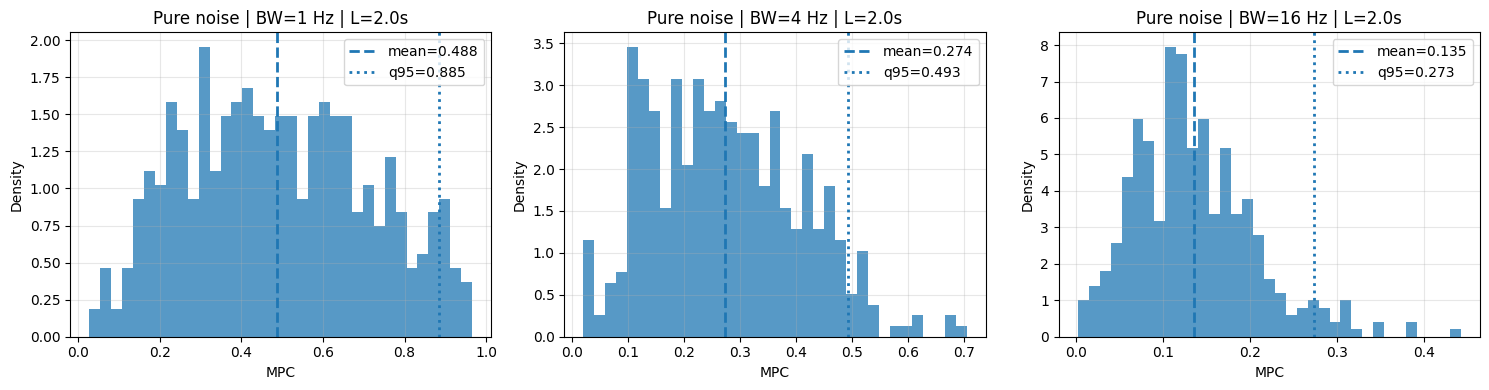

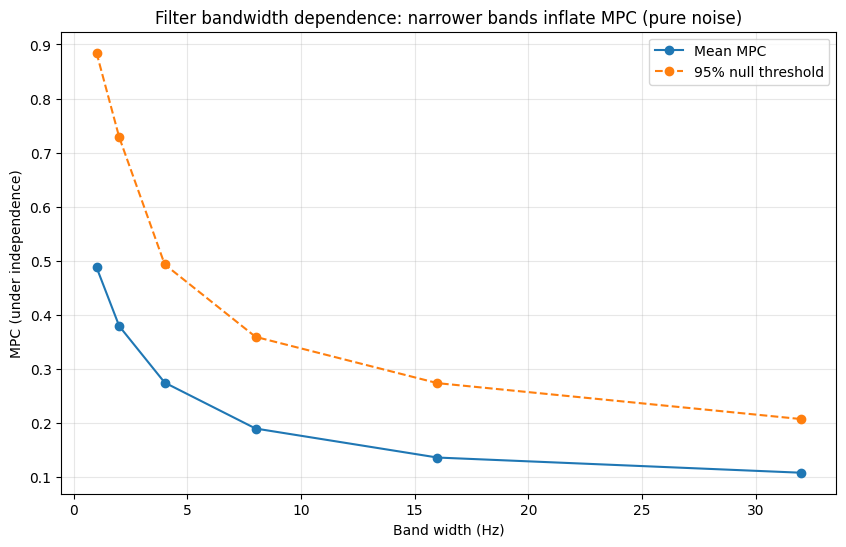

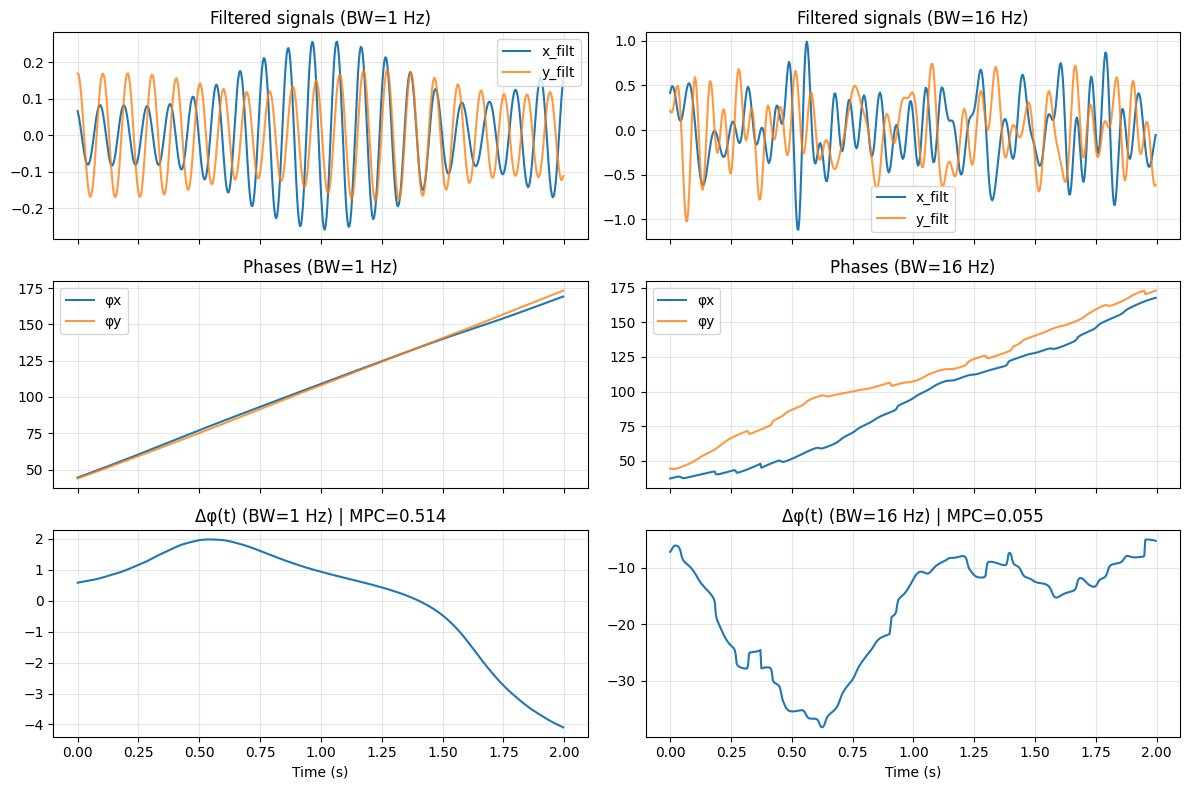


B) MPC under independence vs bandwidth (pure noise), L=2.0s, f0=10.0 Hz
  BW=  1.0 Hz | mean=0.488 | q95=0.885
  BW=  2.0 Hz | mean=0.379 | q95=0.728
  BW=  4.0 Hz | mean=0.274 | q95=0.493
  BW=  8.0 Hz | mean=0.189 | q95=0.359
  BW= 16.0 Hz | mean=0.135 | q95=0.273
  BW= 32.0 Hz | mean=0.107 | q95=0.207


In [1]:
# ============================================================
# O1.B — Filter bandwidth dependence (ONLY bandwidth varies)
#
# Goal:
#   Show that narrowing the bandpass filter can inflate MPC
#   even under independence, because it stabilizes instantaneous phase.
#
# Fixed:
#   - Window length L
#   - Sampling rate fs
#   - Signal model: independent pure noise
#
# Varied:
#   - Bandwidth (Hz) around a center frequency f0
#
# Pipeline:
#   noise -> FFT bandpass -> Hilbert analytic signal -> phase -> Δphi -> MPC
#
# Notes:
#   - Uses FFT bandpass (fast) and FFT-based Hilbert (numpy-only).
#   - Computes distributions of MPC for each bandwidth (n_reps trials).
#   - Produces:
#       (1) Histogram grid for selected bandwidths
#       (2) Mean and 95% vs bandwidth curve
#       (3) Example pipeline visualization: filtered signals, phases, Δphi
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Optional progress bar
try:
    from tqdm.auto import tqdm
    _tqdm = tqdm
except Exception:
    def _tqdm(x, **kwargs):
        return x

rng = np.random.default_rng(0)

# ------------------- settings -------------------
fs = 256
L = 2.0                     # seconds (fixed window length for B)
N = int(L * fs)

edge_trim_s = 1.0           # trim edges after bandpass/Hilbert to reduce boundary artefacts
edge_trim = int(edge_trim_s * fs)
extra_buffer_s = 2.0        # extra data so trimming + random window selection is safe

n_reps = 400                # number of independent trials per bandwidth (lower if slow)

f0 = 10.0                   # center frequency for the bandpass (Hz)
bandwidths = np.array([1, 2, 4, 8, 16, 32], dtype=float)  # total band width in Hz

# ------------------- helpers -------------------
def fft_bandpass_batch(X, fs, f_low, f_high):
    """
    Fast bandpass filtering by zeroing FFT bins outside [f_low, f_high].
    X shape: (n_trials, n_samples)
    """
    n = X.shape[1]
    freqs = np.fft.rfftfreq(n, d=1/fs)
    mask = (freqs >= f_low) & (freqs <= f_high)
    Xf = np.fft.rfft(X, axis=1)
    Xf *= mask[None, :]
    return np.fft.irfft(Xf, n=n, axis=1)

def hilbert_phase_batch(X):
    """
    Analytic signal via FFT Hilbert transform multiplier, then unwrapped phase.
    X shape: (n_trials, n_samples)
    """
    n = X.shape[1]
    Xf = np.fft.fft(X, axis=1)

    H = np.zeros(n)
    if n % 2 == 0:
        H[0] = 1
        H[n//2] = 1
        H[1:n//2] = 2
    else:
        H[0] = 1
        H[1:(n+1)//2] = 2

    Xa = np.fft.ifft(Xf * H[None, :], axis=1)
    phi = np.unwrap(np.angle(Xa), axis=1)
    return phi

def mpc_from_dphi(dphi):
    # MPC as in paper: |(1/N) sum exp(i Δphi)|
    return np.abs(np.mean(np.exp(1j * dphi), axis=-1))

# ------------------- prepare one long dataset (shared across bandwidths) -------------------
T_total = L + 2*edge_trim_s + extra_buffer_s
n_total = int(T_total * fs)

# Generate independent pure noise signals (fixed condition)
X = rng.standard_normal((n_reps, n_total))
Y = rng.standard_normal((n_reps, n_total))

# Define fixed random windows (same starts used for all bandwidths -> fair comparison)
n_after_trim = n_total - 2*edge_trim
max_start = n_after_trim - N
starts = rng.integers(0, max_start, size=n_reps)
idx = starts[:, None] + np.arange(N)[None, :]  # (n_reps, N)

# ------------------- main experiment: MPC distributions vs bandwidth -------------------
results = {}  # results[bw] = array of MPC values (len n_reps)

for bw in _tqdm(bandwidths, desc="Computing MPC vs bandwidth (pure noise)"):
    f_low = max(0.1, f0 - bw/2)
    f_high = f0 + bw/2

    # Bandpass (fast FFT mask)
    Xb = fft_bandpass_batch(X, fs, f_low, f_high)
    Yb = fft_bandpass_batch(Y, fs, f_low, f_high)

    # Trim edges once band-limited
    Xb = Xb[:, edge_trim:-edge_trim]
    Yb = Yb[:, edge_trim:-edge_trim]

    # Hilbert phase
    phX = hilbert_phase_batch(Xb)
    phY = hilbert_phase_batch(Yb)

    # Extract fixed windows and compute phase difference
    dphi_win = phX[np.arange(n_reps)[:, None], idx] - phY[np.arange(n_reps)[:, None], idx]

    # MPC distribution for this bandwidth
    results[bw] = mpc_from_dphi(dphi_win)

# ------------------- 1) Histogram grid for selected bandwidths -------------------
bw_show = [1.0, 4.0, 16.0]  # narrow, medium, wide (change if you like)

fig, axes = plt.subplots(1, len(bw_show), figsize=(15, 4), sharey=False)
if len(bw_show) == 1:
    axes = [axes]

for ax, bw in zip(axes, bw_show):
    vals = results[bw]
    ax.hist(vals, bins=35, density=True, alpha=0.75)
    ax.axvline(vals.mean(), linestyle="--", linewidth=2, label=f"mean={vals.mean():.3f}")
    ax.axvline(np.quantile(vals, 0.95), linestyle=":", linewidth=2,
               label=f"q95={np.quantile(vals,0.95):.3f}")
    ax.set_title(f"Pure noise | BW={bw:.0f} Hz | L={L}s")
    ax.set_xlabel("MPC")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# ------------------- 2) Summary curves: mean & 95% vs bandwidth -------------------
means = np.array([results[bw].mean() for bw in bandwidths])
q95s  = np.array([np.quantile(results[bw], 0.95) for bw in bandwidths])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bandwidths, means, marker="o", label="Mean MPC")
ax.plot(bandwidths, q95s, marker="o", linestyle="--", label="95% null threshold")
#ax.set_xscale("log")
ax.set_xlabel("Band width (Hz)")
ax.set_ylabel("MPC (under independence)")
ax.set_title("Filter bandwidth dependence: narrower bands inflate MPC (pure noise)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# ------------------- 3) Pipeline visualization: narrow vs wide bandwidth (single example trial) -------------------
bw_narrow, bw_wide = 1.0, 16.0

# Choose one trial and use its same start for windowing
trial = 0
start = starts[trial]
win = slice(start, start + N)
tt = np.arange(N) / fs

# Make one fresh single pair for clean visualization
x = rng.standard_normal(n_total)
y = rng.standard_normal(n_total)

def pipeline_single(x_full, y_full, bw):
    f_low = max(0.1, f0 - bw/2)
    f_high = f0 + bw/2

    # bandpass
    xb = fft_bandpass_batch(x_full[None, :], fs, f_low, f_high)[0]
    yb = fft_bandpass_batch(y_full[None, :], fs, f_low, f_high)[0]

    # trim
    xb = xb[edge_trim:-edge_trim]
    yb = yb[edge_trim:-edge_trim]

    # phase
    phx = hilbert_phase_batch(xb[None, :])[0]
    phy = hilbert_phase_batch(yb[None, :])[0]

    # window
    xb_w = xb[win]
    yb_w = yb[win]
    phx_w = phx[win]
    phy_w = phy[win]
    dphi_w = phx_w - phy_w
    mpc_val = mpc_from_dphi(dphi_w[None, :])[0]
    return xb_w, yb_w, phx_w, phy_w, dphi_w, mpc_val

Xn, Yn, phXn, phYn, dphin, mpc_n = pipeline_single(x, y, bw_narrow)
Xw, Yw, phXw, phYw, dphiw, mpc_w = pipeline_single(x, y, bw_wide)

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

# filtered signals
axes[0, 0].plot(tt, Xn, label="x_filt")
axes[0, 0].plot(tt, Yn, label="y_filt", alpha=0.8)
axes[0, 0].set_title(f"Filtered signals (BW={bw_narrow:.0f} Hz)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(tt, Xw, label="x_filt")
axes[0, 1].plot(tt, Yw, label="y_filt", alpha=0.8)
axes[0, 1].set_title(f"Filtered signals (BW={bw_wide:.0f} Hz)")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# phases
axes[1, 0].plot(tt, phXn, label="φx")
axes[1, 0].plot(tt, phYn, label="φy", alpha=0.8)
axes[1, 0].set_title(f"Phases (BW={bw_narrow:.0f} Hz)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(tt, phXw, label="φx")
axes[1, 1].plot(tt, phYw, label="φy", alpha=0.8)
axes[1, 1].set_title(f"Phases (BW={bw_wide:.0f} Hz)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# phase differences
axes[2, 0].plot(tt, dphin)
axes[2, 0].set_title(f"Δφ(t) (BW={bw_narrow:.0f} Hz) | MPC={mpc_n:.3f}")
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlabel("Time (s)")

axes[2, 1].plot(tt, dphiw)
axes[2, 1].set_title(f"Δφ(t) (BW={bw_wide:.0f} Hz) | MPC={mpc_w:.3f}")
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# ------------------- 4) Print a simple table -------------------
print(f"\nB) MPC under independence vs bandwidth (pure noise), L={L}s, f0={f0} Hz")
for bw in bandwidths:
    vals = results[bw]
    print(f"  BW={bw:>5.1f} Hz | mean={vals.mean():.3f} | q95={np.quantile(vals,0.95):.3f}")


Filtered signals (BW = 1 Hz)

→ very sinusoidal

→ smooth phase

→ slow Δφ(t) drift

→ large MPC

Filtered signals (BW = 16 Hz)

→ messy waveform

→ fast phase fluctuations

→ fast Δφ(t)

→ smaller MPC

Restricting phase freedom inflates MPC